# Đánh giá tổng hợp: Đánh giá InceptionResNet (anti-overfit) trên tập Test

Notebook này:
1. Load checkpoint từ `model_v2_result/`
2. Tìm threshold tối ưu cho từng bệnh từ **validation set**
3. Đánh giá trên **test set** với threshold đã freeze
4. Báo cáo: Macro AUC-ROC, Macro F1 (F1opt), Hamming Loss, Cohen's Kappa
5. Vẽ ROC curves, heatmap AUC per class, confusion matrices

**Các model được đánh giá:**
- InceptionResNet (original)
- InceptionResNet (anti-overfit)
- ResNet50
- EfficientNetB3

**Lưu ý**: Test set chỉ được chạm đúng 1 lần (không dùng để tìm threshold).

In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    f1_score, confusion_matrix,
    cohen_kappa_score, hamming_loss
)
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

TARGET_COLS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
LABEL_NAMES = {
    'N': 'Normal', 'D': 'Diabetic Retinopathy', 'G': 'Glaucoma',
    'C': 'Cataract', 'A': 'AMD', 'H': 'Hypertension', 'M': 'Myopia', 'O': 'Other'
}

/home/centrala/work/ou/kltn/Ocular-Disease-Recognition/venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
PROJECT_ROOT = '/home/centrala/work/ou/kltn/Ocular-Disease-Recognition'
PREPROC_DIR  = f'{PROJECT_ROOT}/odir-data-preprocess-augmentation'
MODEL_DIR    = f'{PROJECT_ROOT}/model_v2'
RESULT_DIR   = f'{PROJECT_ROOT}/model_v2_result'

# Cấu hình model từ model_v2_result
MODELS_CONFIG = [
    {
        'name':          'InceptionResNet (anti-overfit)',
        'backbone':      'inception_resnet_v2',
        'image_size':    299,
        'use_batchnorm': True,
        'checkpoint':    f'{RESULT_DIR}/inceptionresnet_v2/checkpoints/inceptionresnet_best.pth',
        'proj_dim': 128, 'tabular_dim': 16, 'dropout': 0.4,
    }
]

# Kiểm tra checkpoint
for cfg in MODELS_CONFIG:
    if os.path.exists(cfg['checkpoint']):
        print(f"{cfg['name']}: checkpoint found")
    else:
        print(f"{cfg['name']}: ⚠️ checkpoint NOT found: {cfg['checkpoint']}")

InceptionResNet (anti-overfit): checkpoint found


## 1. Load dữ liệu

In [3]:
meta_df = pd.read_csv(f'{PREPROC_DIR}/split_metadata.csv')
# norm_params giống nhau giữa các model — dùng từ inceptionresnet
with open(f'{RESULT_DIR}/inceptionresnet/norm_params.json') as f:
    norm_params = json.load(f)
AGE_MEAN = norm_params['age_mean']
AGE_STD  = norm_params['age_std']

val_df  = meta_df[(meta_df['split'] == 'val') &
                  (meta_df['aug_id'].fillna(-1) == -1)].reset_index(drop=True)
test_df = meta_df[meta_df['split'] == 'test'].reset_index(drop=True)

print(f'Val rows: {len(val_df)} | Test rows: {len(test_df)}')

Val rows: 697 | Test rows: 350


## 2. Dataset, Model, Inference functions

In [4]:
def encode_gender(gender_str):
    s = str(gender_str).strip().lower()
    return [1.0, 0.0] if s in ('male', 'm') else [0.0, 1.0]


class OdirDataset(Dataset):
    def __init__(self, df, target_cols, image_size, age_mean, age_std):
        self.df          = df.reset_index(drop=True)
        self.target_cols = target_cols
        self.age_mean    = age_mean
        self.age_std     = age_std
        self.transform   = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        left_t   = self.transform(Image.open(row['left_path']).convert('RGB'))
        right_t  = self.transform(Image.open(row['right_path']).convert('RGB'))
        age_norm = (row['age'] - self.age_mean) / (self.age_std + 1e-8)
        tabular  = torch.tensor([age_norm] + encode_gender(row['gender']), dtype=torch.float32)
        labels   = torch.tensor([float(row[c]) for c in self.target_cols], dtype=torch.float32)
        return left_t, right_t, tabular, labels


class SiameseMultimodalNet(nn.Module):
    def __init__(self, backbone_name, proj_dim=128, tabular_dim=16,
                 dropout=0.4, num_classes=8, use_batchnorm=False):
        super().__init__()
        self.backbone        = timm.create_model(backbone_name, pretrained=False,
                                                 num_classes=0, global_pool='avg')
        feat_dim             = self.backbone.num_features
        self.projector       = nn.Sequential(
            nn.Linear(feat_dim, proj_dim), nn.ReLU(inplace=True), nn.Dropout(dropout)
        )
        self.tabular_encoder = nn.Sequential(
            nn.Linear(3, tabular_dim), nn.ReLU(inplace=True)
        )
        fused_dim = 2 * proj_dim + tabular_dim
        if use_batchnorm:
            self.classifier = nn.Sequential(
                nn.Linear(fused_dim, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True), nn.Dropout(dropout),
                nn.Linear(64, num_classes)
            )
        else:
            self.classifier = nn.Sequential(
                nn.Linear(fused_dim, 64),
                nn.ReLU(inplace=True), nn.Dropout(dropout),
                nn.Linear(64, num_classes)
            )

    def forward_one(self, x):
        return self.projector(self.backbone(x))

    def forward(self, left, right, tabular):
        img_feat = torch.cat([self.forward_one(left), self.forward_one(right)], dim=1)
        return self.classifier(torch.cat([img_feat, self.tabular_encoder(tabular)], dim=1))


def run_inference(model, df, image_size, age_mean, age_std, batch_size=32):
    """Trả về: (probs [N, 8], labels [N, 8])"""
    dataset = OdirDataset(df, TARGET_COLS, image_size, age_mean, age_std)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                         num_workers=4, pin_memory=True)
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for left, right, tabular, labels in loader:
            left, right, tabular = left.to(device), right.to(device), tabular.to(device)
            probs = torch.sigmoid(model(left, right, tabular)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)


print('Classes và functions OK')

Classes và functions OK


## 3. Hàm tính metrics

In [5]:
def find_optimal_thresholds(val_probs, val_labels,
                             threshold_range=np.arange(0.1, 0.91, 0.05)):
    """
    Tìm threshold tối ưu per class trên VALIDATION SET bằng cách maximize F1.
    Threshold này sẽ được freeze và áp dụng trên test set.
    """
    optimal_thresholds = {}
    for i, col in enumerate(TARGET_COLS):
        best_f1, best_thresh = 0.0, 0.5
        for thresh in threshold_range:
            preds = (val_probs[:, i] >= thresh).astype(int)
            f1    = f1_score(val_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_thresh = f1, thresh
        optimal_thresholds[col] = round(float(best_thresh), 2)
    return optimal_thresholds


def compute_macro_kappa(y_true, y_pred_binary):
    """
    Cohen's Kappa: tính per class (binary) rồi macro average.
    KHÔNG flatten multi-label array — sẽ cho kết quả sai.
    """
    kappas = []
    for i in range(y_true.shape[1]):
        try:
            k = cohen_kappa_score(y_true[:, i], y_pred_binary[:, i])
        except Exception:
            k = 0.0
        kappas.append(k)
    return np.mean(kappas), kappas


print('Metric functions OK')

Metric functions OK


## 4. Vòng lặp đánh giá tất cả model

In [6]:
results = {}

for cfg in MODELS_CONFIG:
    if not os.path.exists(cfg['checkpoint']):
        print(f"[SKIP] {cfg['name']}: checkpoint không tồn tại")
        continue

    print(f"\n{'='*60}")
    print(f"Đánh giá: {cfg['name']} ({cfg['backbone']})")

    # Load model
    model = SiameseMultimodalNet(
        backbone_name=cfg['backbone'],
        proj_dim=cfg['proj_dim'],
        tabular_dim=cfg['tabular_dim'],
        dropout=cfg['dropout'],
        num_classes=len(TARGET_COLS),
        use_batchnorm=cfg.get('use_batchnorm', False)
    ).to(device)
    checkpoint = torch.load(cfg['checkpoint'], map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Loaded từ epoch {checkpoint.get('epoch', '?')}")

    # Bước 1: Inference trên VALIDATION set → tìm optimal thresholds
    val_probs, val_labels = run_inference(model, val_df, cfg['image_size'], AGE_MEAN, AGE_STD)
    opt_thresh = find_optimal_thresholds(val_probs, val_labels)
    print(f"  Optimal thresholds: {opt_thresh}")

    # Bước 2: Inference trên TEST set (chỉ 1 lần)
    test_probs, test_labels = run_inference(model, test_df, cfg['image_size'], AGE_MEAN, AGE_STD)

    # Áp dụng optimal thresholds
    test_preds = np.zeros_like(test_probs, dtype=int)
    for i, col in enumerate(TARGET_COLS):
        test_preds[:, i] = (test_probs[:, i] >= opt_thresh[col]).astype(int)

    # Tính metrics
    macro_auc          = roc_auc_score(test_labels, test_probs, average='macro')
    per_class_auc      = roc_auc_score(test_labels, test_probs, average=None)
    macro_f1           = f1_score(test_labels, test_preds, average='macro', zero_division=0)
    h_loss             = hamming_loss(test_labels, test_preds)
    kappa_mean, kappas = compute_macro_kappa(test_labels, test_preds)

    results[cfg['name']] = {
        'macro_auc':          macro_auc,
        'macro_f1_opt':       macro_f1,
        'hamming_loss':       h_loss,
        'macro_kappa':        kappa_mean,
        'per_class_auc':      dict(zip(TARGET_COLS, per_class_auc.tolist())),
        'per_class_kappa':    dict(zip(TARGET_COLS, kappas)),
        'optimal_thresholds': opt_thresh,
        'test_probs':         test_probs,
        'test_labels':        test_labels,
        'test_preds':         test_preds,
    }

    print(f"  Macro AUC={macro_auc:.4f} | Macro F1(opt)={macro_f1:.4f} | "
          f"Hamming={h_loss:.4f} | Kappa={kappa_mean:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nĐánh giá hoàn thành!')


Đánh giá: InceptionResNet (anti-overfit) (inception_resnet_v2)
  Loaded từ epoch 13
  Optimal thresholds: {'N': 0.35, 'D': 0.45, 'G': 0.7, 'C': 0.85, 'A': 0.9, 'H': 0.7, 'M': 0.65, 'O': 0.45}
  Macro AUC=0.8445 | Macro F1(opt)=0.6000 | Hamming=0.1350 | Kappa=0.5030

Đánh giá hoàn thành!


## 5. Bảng so sánh

In [7]:
comparison_rows = []
for name, r in results.items():
    comparison_rows.append({
        'Model':             name,
        'Macro AUC-ROC':     f"{r['macro_auc']:.4f}",
        'Macro F1 (F1opt)':  f"{r['macro_f1_opt']:.4f}",
        'Hamming Loss':      f"{r['hamming_loss']:.4f}",
        'Cohen Kappa':       f"{r['macro_kappa']:.4f}",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(f'{MODEL_DIR}/10_evaluation_inceptionresnet_comparison.csv', index=False)
print('Saved: 10_evaluation_inceptionresnet_comparison.csv')
display(comparison_df)

Saved: 10_evaluation_inceptionresnet_comparison.csv


,Model,Macro AUC-ROC,Macro F1 (F1opt),Hamming Loss,Cohen Kappa
0,InceptionResNet (anti-overfit),0.8445,0.6000,0.1350,0.5030


## 6. Heatmap AUC per class

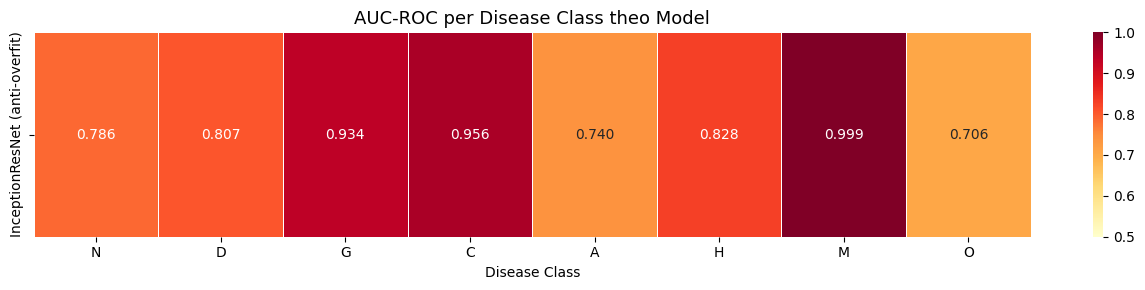

Saved: 10_chart_inceptionresnet_per_class_auc_heatmap.png


In [8]:
if results:
    auc_data = pd.DataFrame(
        {name: r['per_class_auc'] for name, r in results.items()}
    ).T

    fig, ax = plt.subplots(figsize=(13, max(3, len(results) + 1)))
    sns.heatmap(auc_data, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5)
    ax.set_title('AUC-ROC per Disease Class theo Model', fontsize=13)
    ax.set_xlabel('Disease Class')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/10_chart_inceptionresnet_per_class_auc_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: 10_chart_inceptionresnet_per_class_auc_heatmap.png')

## 7. ROC Curves — 8 subplots, 1 model

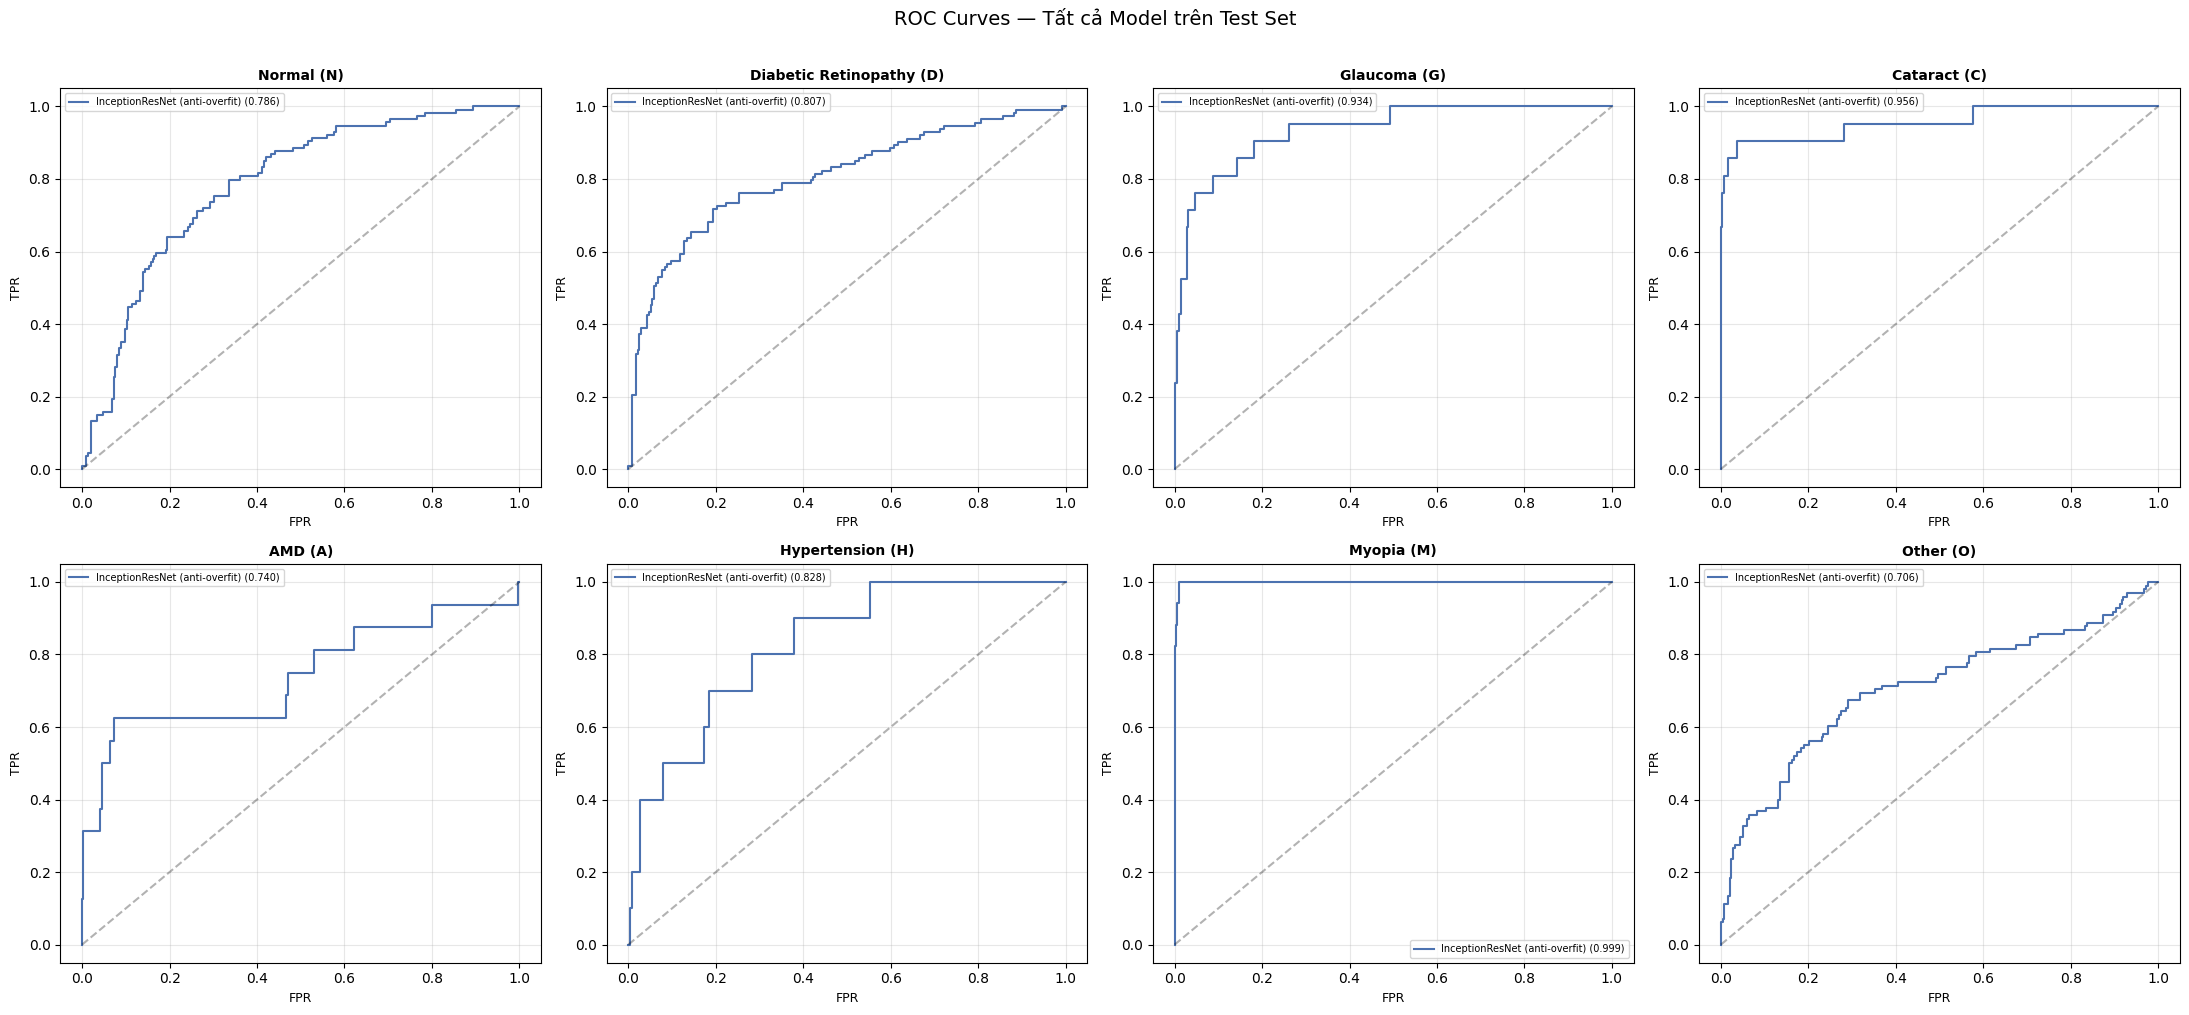

Saved: 10_chart_inceptionresnet_roc_curves.png


In [9]:
if results:
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()

    for i, col in enumerate(TARGET_COLS):
        for j, (name, r) in enumerate(results.items()):
            fpr, tpr, _ = roc_curve(r['test_labels'][:, i], r['test_probs'][:, i])
            auc_val      = r['per_class_auc'][col]
            axes[i].plot(fpr, tpr, color=colors[j % len(colors)],
                         label=f"{name} ({auc_val:.3f})", linewidth=1.5)
        axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.3)
        axes[i].set_title(f'{LABEL_NAMES[col]} ({col})', fontsize=10, fontweight='bold')
        axes[i].set_xlabel('FPR', fontsize=9)
        axes[i].set_ylabel('TPR', fontsize=9)
        axes[i].legend(fontsize=7)
        axes[i].grid(alpha=0.3)

    plt.suptitle('ROC Curves — Tất cả Model trên Test Set', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/10_chart_inceptionresnet_roc_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: 10_chart_inceptionresnet_roc_curves.png')

## 8. Confusion Matrices (Best Model)

Best model (Macro AUC): InceptionResNet (anti-overfit) — AUC=0.8445


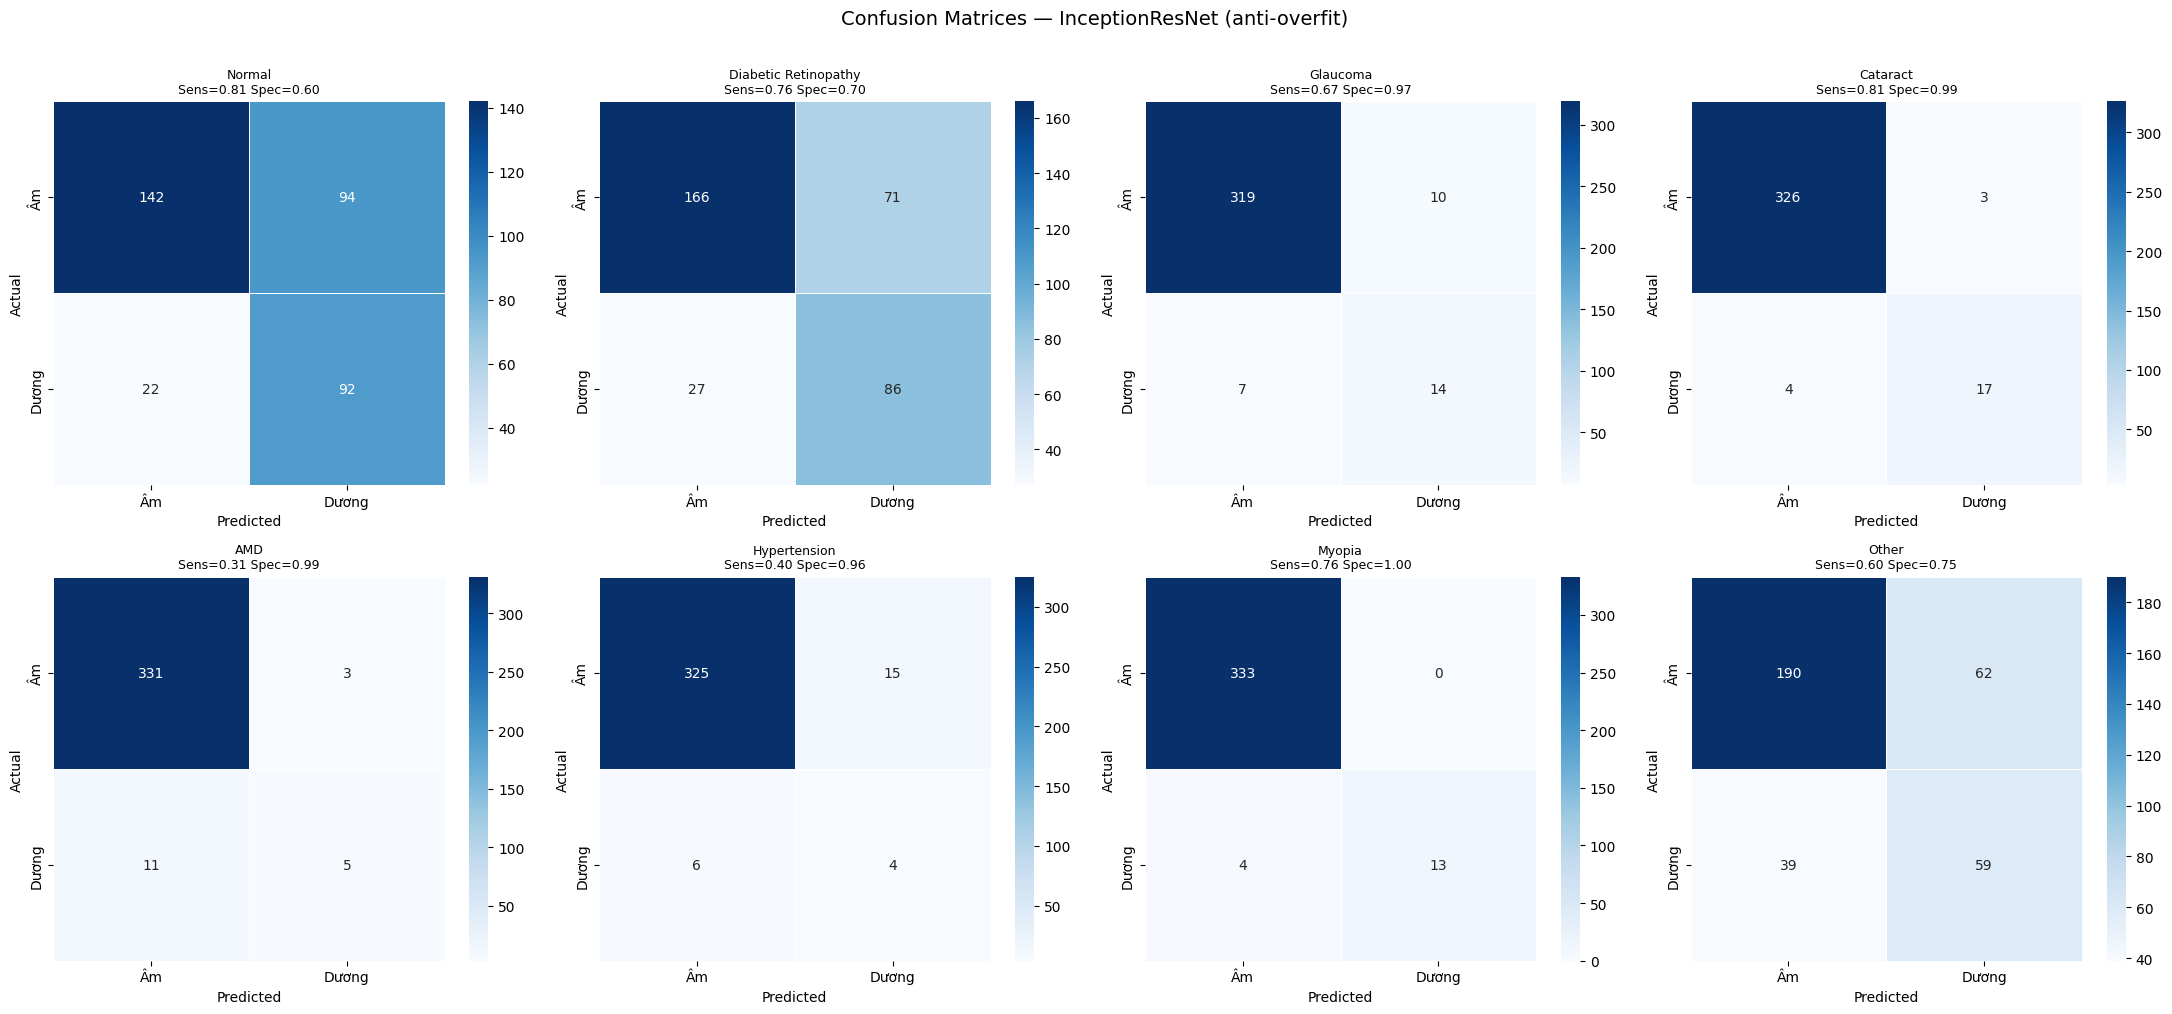

Saved: 10_chart_inceptionresnet_confusion_matrices.png


In [10]:
if results:
    best_model_name = max(results, key=lambda k: results[k]['macro_auc'])
    r = results[best_model_name]
    print(f'Best model (Macro AUC): {best_model_name} — AUC={r["macro_auc"]:.4f}')

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()

    for i, col in enumerate(TARGET_COLS):
        cm = confusion_matrix(r['test_labels'][:, i], r['test_preds'][:, i])
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                    xticklabels=['Âm', 'Dương'], yticklabels=['Âm', 'Dương'],
                    linewidths=0.5)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], 0, 0, cm[1,1])
        sensitivity = tp / (tp + fn + 1e-8)
        specificity = tn / (tn + fp + 1e-8)
        axes[i].set_title(
            f"{LABEL_NAMES[col]}\nSens={sensitivity:.2f} Spec={specificity:.2f}",
            fontsize=9
        )
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    plt.suptitle(f'Confusion Matrices — {best_model_name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/10_chart_inceptionresnet_confusion_matrices.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: 10_chart_inceptionresnet_confusion_matrices.png')

## 9. Bar Chart So sánh tổng hợp

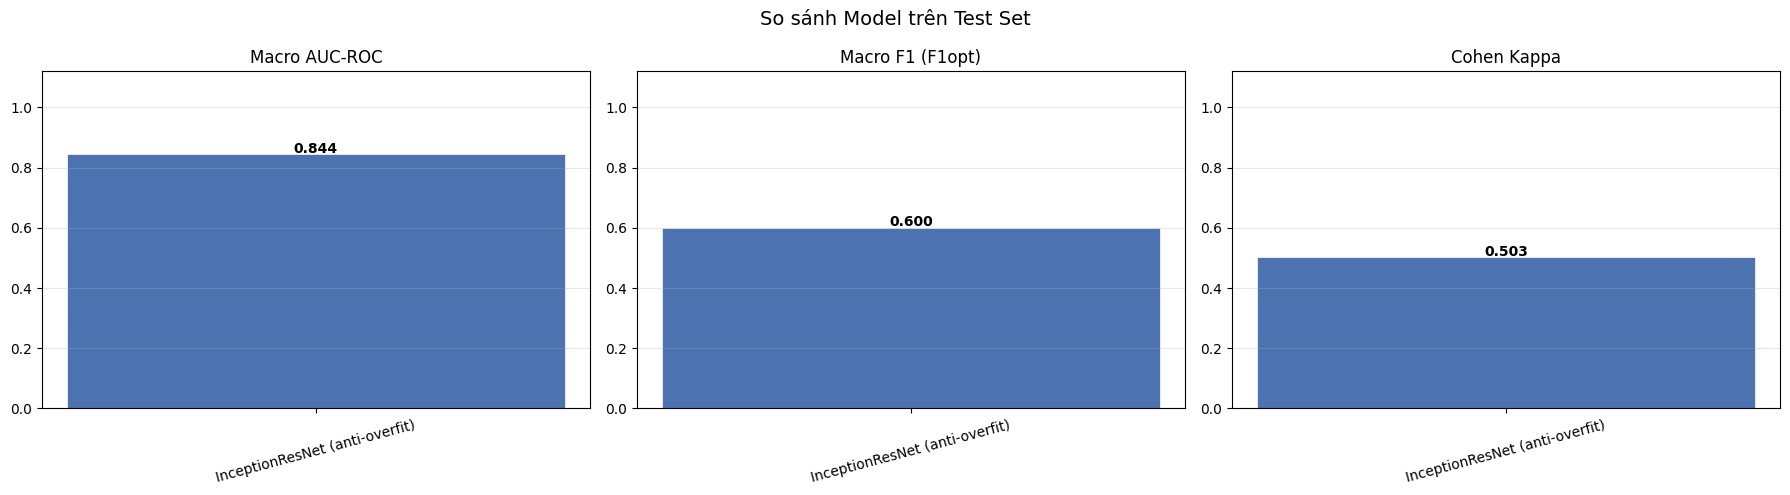

Saved: 10_chart_inceptionresnet_model_comparison.png


In [11]:
if results:
    model_names = list(results.keys())
    metrics_info = [
        ('macro_auc',    'Macro AUC-ROC',    '#4C72B0'),
        ('macro_f1_opt', 'Macro F1 (F1opt)', '#DD8452'),
        ('macro_kappa',  'Cohen Kappa',       '#55A868'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    palette   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for ax, (metric_key, metric_label, _) in zip(axes, metrics_info):
        vals = [results[n][metric_key] for n in model_names]
        bars = ax.bar(model_names, vals, color=palette[:len(model_names)],
                      edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha='center', fontsize=10, fontweight='bold')
        ax.set_title(metric_label, fontsize=12)
        ax.set_ylim(0, 1.12)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=15)

    plt.suptitle('So sánh Model trên Test Set', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/10_chart_inceptionresnet_model_comparison.png', dpi=120)
    plt.show()
    print('Saved: 10_chart_inceptionresnet_model_comparison.png')

## 10. Lưu kết quả đầy đủ

In [12]:
# Serialize kết quả (bỏ numpy arrays, chỉ giữ scalar metrics)
serializable = {}
for name, r in results.items():
    serializable[name] = {
        'macro_auc':          float(r['macro_auc']),
        'macro_f1_opt':       float(r['macro_f1_opt']),
        'hamming_loss':       float(r['hamming_loss']),
        'macro_kappa':        float(r['macro_kappa']),
        'per_class_auc':      {k: float(v) for k, v in r['per_class_auc'].items()},
        'per_class_kappa':    {k: float(v) for k, v in r['per_class_kappa'].items()},
        'optimal_thresholds': r['optimal_thresholds'],
    }

results_path = f'{MODEL_DIR}/10_evaluation_inceptionresnet_results.json'
with open(results_path, 'w') as f:
    json.dump(serializable, f, indent=2, ensure_ascii=False)
print(f'Saved: {results_path}')

print('\n=== TÓM TẮT ===')
for name, r in serializable.items():
    print(f"{name}: AUC={r['macro_auc']:.4f} F1={r['macro_f1_opt']:.4f} "
          f"Kappa={r['macro_kappa']:.4f} Hamming={r['hamming_loss']:.4f}")

Saved: /home/centrala/work/ou/kltn/Ocular-Disease-Recognition/model_v2/10_evaluation_inceptionresnet_results.json

=== TÓM TẮT ===
InceptionResNet (anti-overfit): AUC=0.8445 F1=0.6000 Kappa=0.5030 Hamming=0.1350


## 11. Đồ thị Loss và AUC theo Epoch từ quá trình Training

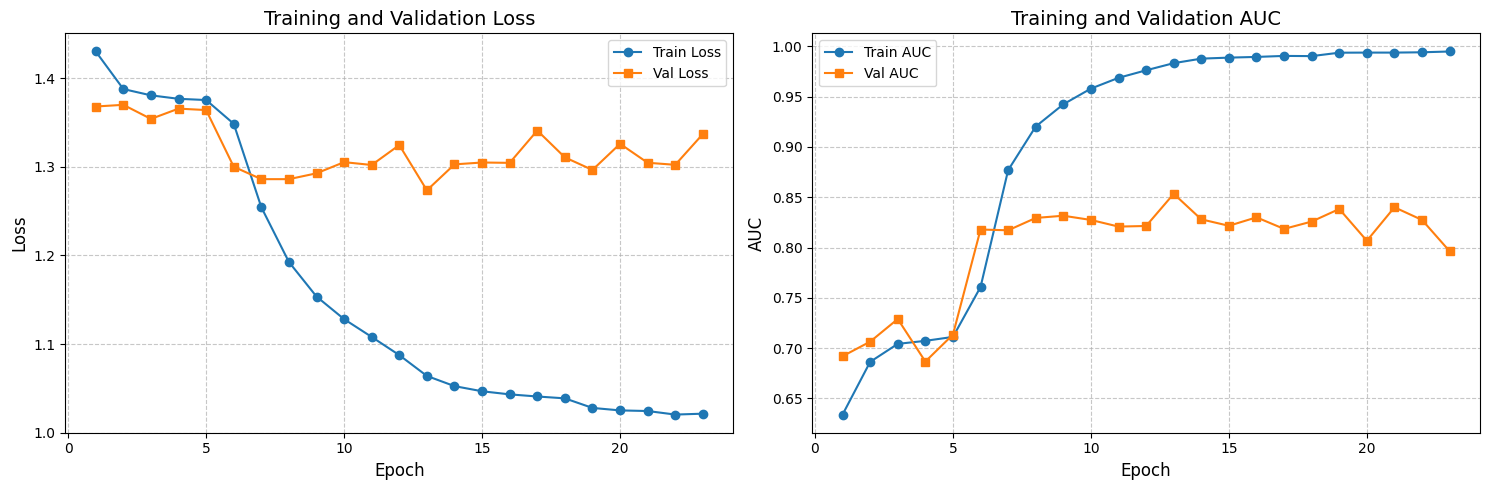

Saved: /home/centrala/work/ou/kltn/Ocular-Disease-Recognition/model_v2/10_chart_inceptionresnet_training_history.png


In [13]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

# Đường dẫn tới notebook training
train_nb_path = f'{RESULT_DIR}/03-model-inceptionresnet-v2-gi-m-overfitting.ipynb'

# Đọc notebook và parse output
with open(train_nb_path, 'r', encoding='utf-8') as f:
    train_nb = json.load(f)

log_text = ""
for cell in train_nb['cells']:
    if cell['cell_type'] == 'code':
        for output in cell.get('outputs', []):
            if output.get('output_type') == 'stream':
                text = "".join(output.get('text', []))
                if 'Train Loss=' in text and 'Val Loss=' in text:
                    log_text += text

# Parse log text
epochs = []
train_loss = []
train_auc = []
val_loss = []
val_auc = []

# Regex pattern: [FINETUNE] Epoch   6/50 | Train Loss=1.3486 AUC=0.7607 | Val Loss=1.3001 AUC=0.8179
pattern = re.compile(r'Epoch\s+(\d+)/\d+\s+\|\s+Train Loss=([\d.]+)\s+AUC=([\d.]+)\s+\|\s+Val Loss=([\d.]+)\s+AUC=([\d.]+)')

for line in log_text.split('\n'):
    match = pattern.search(line)
    if match:
        ep = int(match.group(1))
        t_loss = float(match.group(2))
        t_auc = float(match.group(3))
        v_loss = float(match.group(4))
        v_auc = float(match.group(5))
        
        epochs.append(ep)
        train_loss.append(t_loss)
        train_auc.append(t_auc)
        val_loss.append(v_loss)
        val_auc.append(v_auc)

df_history = pd.DataFrame({
    'Epoch': epochs,
    'Train Loss': train_loss,
    'Train AUC': train_auc,
    'Val Loss': val_loss,
    'Val AUC': val_auc
}).set_index('Epoch')

# Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Chart
ax1.plot(df_history.index, df_history['Train Loss'], label='Train Loss', marker='o')
ax1.plot(df_history.index, df_history['Val Loss'], label='Val Loss', marker='s')
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# AUC Chart
ax2.plot(df_history.index, df_history['Train AUC'], label='Train AUC', marker='o')
ax2.plot(df_history.index, df_history['Val AUC'], label='Val AUC', marker='s')
ax2.set_title('Training and Validation AUC', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('AUC', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
chart_path = f'{MODEL_DIR}/10_chart_inceptionresnet_training_history.png'
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {chart_path}')

## Outputs
- `model_v2/10_evaluation_inceptionresnet_comparison.csv` — bảng so sánh tóm tắt
- `model_v2/10_evaluation_inceptionresnet_results.json` — kết quả đầy đủ
- `model_v2/10_chart_inceptionresnet_per_class_auc_heatmap.png`
- `model_v2/10_chart_inceptionresnet_roc_curves.png`
- `model_v2/10_chart_inceptionresnet_confusion_matrices.png`
- `model_v2/10_chart_inceptionresnet_model_comparison.png`

**Models so sánh từ `model_v2_result/`:**
- InceptionResNet (original) — `inceptionresnet/`
- InceptionResNet (anti-overfit) — `inceptionresnet_v2/`
- ResNet50 — `resnet50/`
- EfficientNetB3 — `efficientnetb3/`\n
- `model_v2/10_chart_inceptionresnet_training_history.png`